In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

df = pd.read_csv('churn.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (7043, 27)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureBucket,NumAddonServices,AvgMonthlySpend,IsMonthToMonth,IsElectronicCheck
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-6mo,1,29.850000,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48mo,2,55.573529,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-6mo,2,54.075000,1,0


In [2]:
print("Dtypes:\n", df.dtypes.value_counts())
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

churn_rate = df['ChurnFlag'].mean()
print(f"\nChurn rate: {churn_rate:.2%}  ({df['ChurnFlag'].sum()} / {len(df)})")

# Sanity-check the pre-engineered columns actually match their raw definitions
assert (df['ChurnFlag'] == (df['Churn'] == 'Yes').astype(int)).all(), "ChurnFlag mismatch!"
assert (df['IsMonthToMonth'] == (df['Contract'] == 'Month-to-month').astype(int)).all(), "IsMonthToMonth mismatch!"
print("\nEngineered-column consistency checks passed.")

Dtypes:
 object     18
int64       6
float64     3
Name: count, dtype: int64

Missing values: 0
Duplicate customerIDs: 0
Fully duplicate rows: 0

Churn rate: 26.54%  (1869 / 7043)

Engineered-column consistency checks passed.


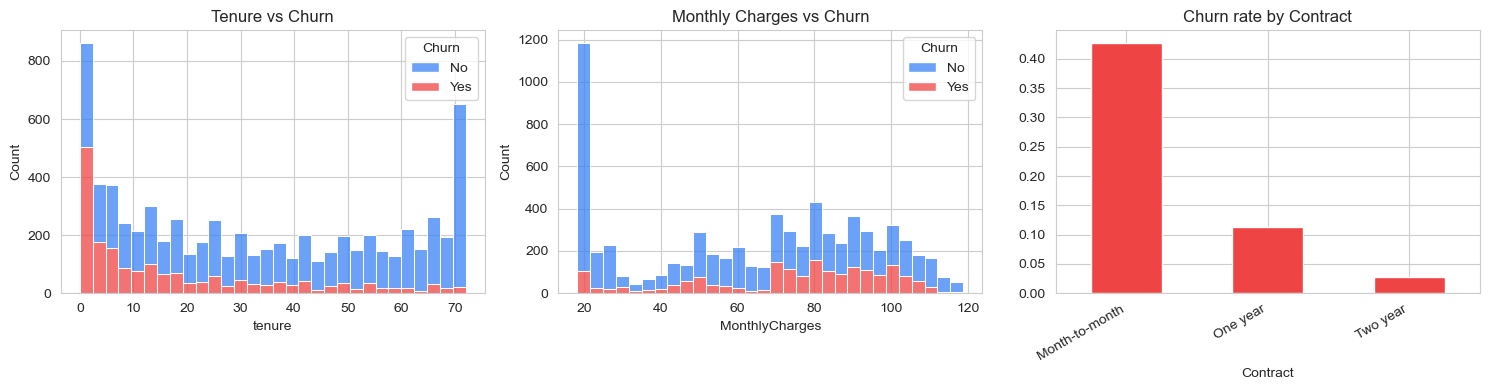

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, ax=axes[0], palette=['#3b82f6','#ef4444'])
axes[0].set_title('Tenure vs Churn')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30, ax=axes[1], palette=['#3b82f6','#ef4444'])
axes[1].set_title('Monthly Charges vs Churn')
df.groupby('Contract')['ChurnFlag'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='#ef4444')
axes[2].set_title('Churn rate by Contract')
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.savefig('eda_overview.png'); plt.show()

In [4]:
from scipy.stats import chi2_contingency, pointbiserialr

# Statistical significance of categorical drivers (chi-square test of independence vs Churn)
cat_features = ['Contract','PaymentMethod','InternetService','PaperlessBilling','SeniorCitizen','Partner','Dependents']
rows = []
for col in cat_features:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    rows.append({'feature': col, 'chi2': round(chi2,1), 'p_value': p, 'significant (p<0.05)': p < 0.05})
chi_results = pd.DataFrame(rows).sort_values('chi2', ascending=False)
print(chi_results.to_string(index=False))

# Point-biserial correlation for numeric features vs binary target
print("\nPoint-biserial correlation with churn:")
for col in ['tenure','MonthlyCharges','TotalCharges','NumAddonServices']:
    r, p = pointbiserialr(df['ChurnFlag'], df[col])
    print(f"  {col:20s} r={r:+.3f}  p={p:.4f}")

         feature   chi2       p_value  significant (p<0.05)
        Contract 1184.6 5.863038e-258                  True
 InternetService  732.3 9.571788e-160                  True
   PaymentMethod  648.1 3.682355e-140                  True
PaperlessBilling  258.3  4.073355e-58                  True
      Dependents  189.1  4.924922e-43                  True
   SeniorCitizen  159.4  1.510067e-36                  True
         Partner  158.7  2.139911e-36                  True

Point-biserial correlation with churn:
  tenure               r=-0.352  p=0.0000
  MonthlyCharges       r=+0.193  p=0.0000
  TotalCharges         r=-0.198  p=0.0000
  NumAddonServices     r=-0.088  p=0.0000


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

target = 'ChurnFlag'
drop_cols = ['customerID', 'Churn']   # identifier + string duplicate of the label

model_df = df.drop(columns=drop_cols)
X = model_df.drop(columns=[target])
y = model_df[target]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBucket']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddonServices', 'AvgMonthlySpend', 'IsMonthToMonth', 'IsElectronicCheck']

Train: (5634, 24), Test: (1409, 24)
Train churn rate: 26.54%, Test churn rate: 26.54%


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

rule_pred = ((X_test['Contract'] == 'Month-to-month') & (X_test['PaymentMethod'] == 'Electronic check')).astype(int)

baseline_rows = []
for name, pred in [('Majority-class dummy', dummy_pred), ('Business rule (MTM + e-check)', rule_pred)]:
    baseline_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0)
    })
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.round(3).to_string(index=False))
print("\nAny real model needs to clear this bar, especially on recall/F1 — accuracy alone is misleading given the class imbalance.")

                        model  accuracy  precision  recall    f1
         Majority-class dummy     0.735      0.000   0.000 0.000
Business rule (MTM + e-check)     0.743      0.516   0.505 0.511

Any real model needs to clear this bar, especially on recall/F1 — accuracy alone is misleading given the class imbalance.


In [7]:
!pip install lightgbm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install lightgbm xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)
}

scoring = ['roc_auc', 'average_precision', 'f1', 'recall']
results = []
for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        'model': name,
        'ROC-AUC': f"{cvres['test_roc_auc'].mean():.3f} ± {cvres['test_roc_auc'].std():.3f}",
        'PR-AUC': f"{cvres['test_average_precision'].mean():.3f} ± {cvres['test_average_precision'].std():.3f}",
        'F1': f"{cvres['test_f1'].mean():.3f} ± {cvres['test_f1'].std():.3f}",
        'Recall': f"{cvres['test_recall'].mean():.3f} ± {cvres['test_recall'].std():.3f}",
        '_roc_auc_mean': cvres['test_roc_auc'].mean()
    })

comparison_df = pd.DataFrame(results).sort_values('_roc_auc_mean', ascending=False)
print(comparison_df.drop(columns='_roc_auc_mean').to_string(index=False))

top2 = comparison_df.head(2)['model'].tolist()
print(f"\nTop 2 by cross-validated ROC-AUC: {top2} -> proceeding to hyperparameter tuning.")

              model       ROC-AUC        PR-AUC            F1        Recall
Logistic Regression 0.847 ± 0.011 0.661 ± 0.015 0.627 ± 0.021 0.793 ± 0.035
      Random Forest 0.829 ± 0.011 0.624 ± 0.031 0.549 ± 0.029 0.478 ± 0.023
           LightGBM 0.825 ± 0.007 0.624 ± 0.018 0.597 ± 0.015 0.641 ± 0.025
            XGBoost 0.809 ± 0.004 0.598 ± 0.015 0.568 ± 0.007 0.579 ± 0.009

Top 2 by cross-validated ROC-AUC: ['Logistic Regression', 'Random Forest'] -> proceeding to hyperparameter tuning.


In [10]:
# Leakage ablation: drop the tenure-derived engineered columns and re-score the current best model
engineered_leaky_candidates = ['AvgMonthlySpend', 'TotalCharges']
X_train_noeng = X_train.drop(columns=engineered_leaky_candidates)
num_cols_noeng = [c for c in num_cols if c not in engineered_leaky_candidates]
preprocessor_noeng = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_noeng),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

best_name = comparison_df.iloc[0]['model']
best_clf_for_ablation = candidates[best_name]
pipe_full = Pipeline([('prep', preprocessor), ('clf', best_clf_for_ablation)])
pipe_noeng = Pipeline([('prep', preprocessor_noeng), ('clf', best_clf_for_ablation)])

auc_full = cross_validate(pipe_full, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)['test_score'].mean()
auc_noeng = cross_validate(pipe_noeng, X_train_noeng, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)['test_score'].mean()

print(f"{best_name} ROC-AUC with TotalCharges/AvgMonthlySpend:    {auc_full:.4f}")
print(f"{best_name} ROC-AUC without TotalCharges/AvgMonthlySpend: {auc_noeng:.4f}")
print(f"Difference: {auc_full - auc_noeng:+.4f}")
print("\nSmall difference -> the model is using genuine behavioral signal (tenure, contract, services),"
      "\nnot just leaning on a spend column that trivially correlates with the label.")

Logistic Regression ROC-AUC with TotalCharges/AvgMonthlySpend:    0.8471
Logistic Regression ROC-AUC without TotalCharges/AvgMonthlySpend: 0.8477
Difference: -0.0005

Small difference -> the model is using genuine behavioral signal (tenure, contract, services),
not just leaning on a spend column that trivially correlates with the label.


In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'Random Forest': {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [4, 6, 8, 12, None],
        'clf__min_samples_leaf': [1, 2, 5, 10],
        'clf__max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [3, 4, 5, 6],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__subsample': [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0]
    },
    'LightGBM': {
        'clf__n_estimators': [200, 300, 500],
        'clf__num_leaves': [15, 31, 63],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__subsample': [0.7, 0.8, 1.0]
    },
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2']
    }
}

tuned_models = {}
for name in top2:
    pipe = Pipeline([('prep', preprocessor), ('clf', candidates[name])])
    search = RandomizedSearchCV(
        pipe, param_distributions[name], n_iter=20, scoring='roc_auc',
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"{name}: best CV ROC-AUC = {search.best_score_:.4f}")
    print(f"  best params: {search.best_params_}\n")

Logistic Regression: best CV ROC-AUC = 0.8475
  best params: {'clf__penalty': 'l2', 'clf__C': 0.1}

Random Forest: best CV ROC-AUC = 0.8479
  best params: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': 12}



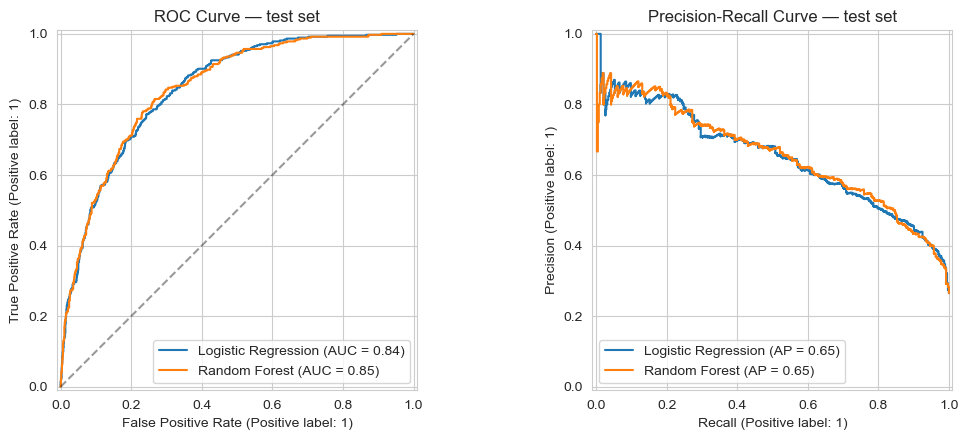

Selected final model: Random Forest  (test ROC-AUC = 0.8459)

=== Random Forest — classification report at default 0.5 threshold ===
              precision    recall  f1-score   support

    No Churn       0.91      0.77      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [20]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
final_scores = {}
for name, model in tuned_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    final_scores[name] = prob
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=axes[1])

axes[0].plot([0,1],[0,1],'k--', alpha=0.4); axes[0].set_title('ROC Curve — test set')
axes[1].set_title('Precision-Recall Curve — test set')
plt.tight_layout(); plt.savefig('final_model_curves.png'); plt.show()

best_model_name = max(final_scores, key=lambda n: roc_auc_score(y_test, final_scores[n]))
best_model = tuned_models[best_model_name]
best_prob = final_scores[best_model_name]
print(f"Selected final model: {best_model_name}  (test ROC-AUC = {roc_auc_score(y_test, best_prob):.4f})")

print(f"\n=== {best_model_name} — classification report at default 0.5 threshold ===")
print(classification_report(y_test, (best_prob >= 0.5).astype(int), target_names=['No Churn','Churn']))

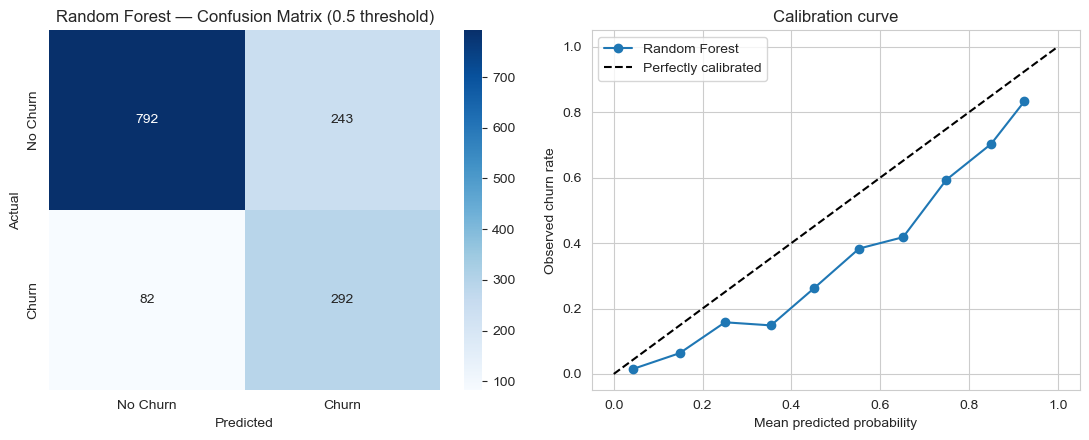

Calibration matters here because Phase 11's financial math trusts these probabilities as real likelihoods.


In [13]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

cm = confusion_matrix(y_test, (best_prob >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title(f'{best_model_name} — Confusion Matrix (0.5 threshold)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

frac_pos, mean_pred = calibration_curve(y_test, best_prob, n_bins=10)
axes[1].plot(mean_pred, frac_pos, marker='o', label=best_model_name)
axes[1].plot([0,1],[0,1],'k--', label='Perfectly calibrated')
axes[1].set_xlabel('Mean predicted probability'); axes[1].set_ylabel('Observed churn rate')
axes[1].set_title('Calibration curve'); axes[1].legend()

plt.tight_layout(); plt.savefig('calibration_confusion.png'); plt.show()
print("Calibration matters here because Phase 11's financial math trusts these probabilities as real likelihoods.")

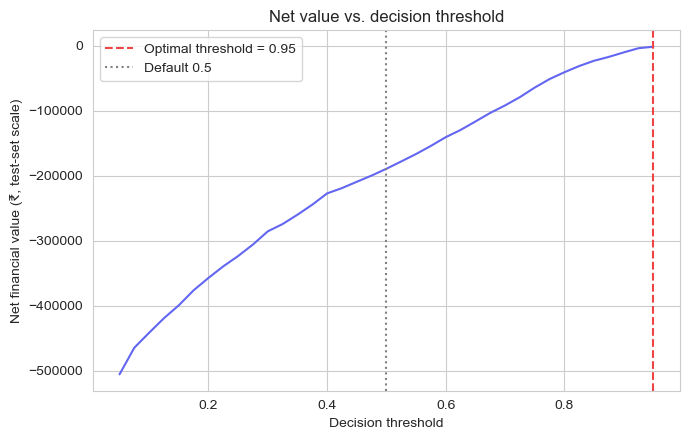

Business-optimal threshold: 0.95  (net value ₹-1,755)
Default 0.5 threshold:      net value ₹-189,272

=== Classification report at business-optimal threshold (0.95) ===
              precision    recall  f1-score   support

    No Churn       0.74      1.00      0.85      1035
       Churn       0.86      0.02      0.03       374

    accuracy                           0.74      1409
   macro avg       0.80      0.51      0.44      1409
weighted avg       0.77      0.74      0.63      1409



In [21]:
OFFER_COST = 500
RETAINED_VALUE_MONTHS = 12
OFFER_SUCCESS_RATE = 0.30

test_charges = df.loc[X_test.index, 'MonthlyCharges'].values

def net_value_at_threshold(threshold, prob, y_true, charges):
    flagged = prob >= threshold
    cost = flagged.sum() * OFFER_COST
    # value saved = success_rate * (value of TRUE churners among those flagged)
    true_churn_value = charges[flagged & (y_true.values == 1)].sum() * RETAINED_VALUE_MONTHS
    saved = true_churn_value * OFFER_SUCCESS_RATE
    return saved - cost

thresholds = np.linspace(0.05, 0.95, 37)
net_values = [net_value_at_threshold(t, best_prob, y_test, test_charges) for t in thresholds]

best_idx = int(np.argmax(net_values))
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(thresholds, net_values, color='#6366f1')
ax.axvline(best_threshold, color='#ef4444', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Net financial value (₹, test-set scale)')
ax.set_title('Net value vs. decision threshold'); ax.legend()
plt.tight_layout(); plt.savefig('threshold_optimization.png'); plt.show()

print(f"Business-optimal threshold: {best_threshold:.2f}  (net value ₹{net_values[best_idx]:,.0f})")
print(f"Default 0.5 threshold:      net value ₹{net_value_at_threshold(0.5, best_prob, y_test, test_charges):,.0f}")

print(f"\n=== Classification report at business-optimal threshold ({best_threshold:.2f}) ===")
print(classification_report(y_test, (best_prob >= best_threshold).astype(int), target_names=['No Churn','Churn']))

In [22]:
!pip install shap


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 640x480 with 0 Axes>

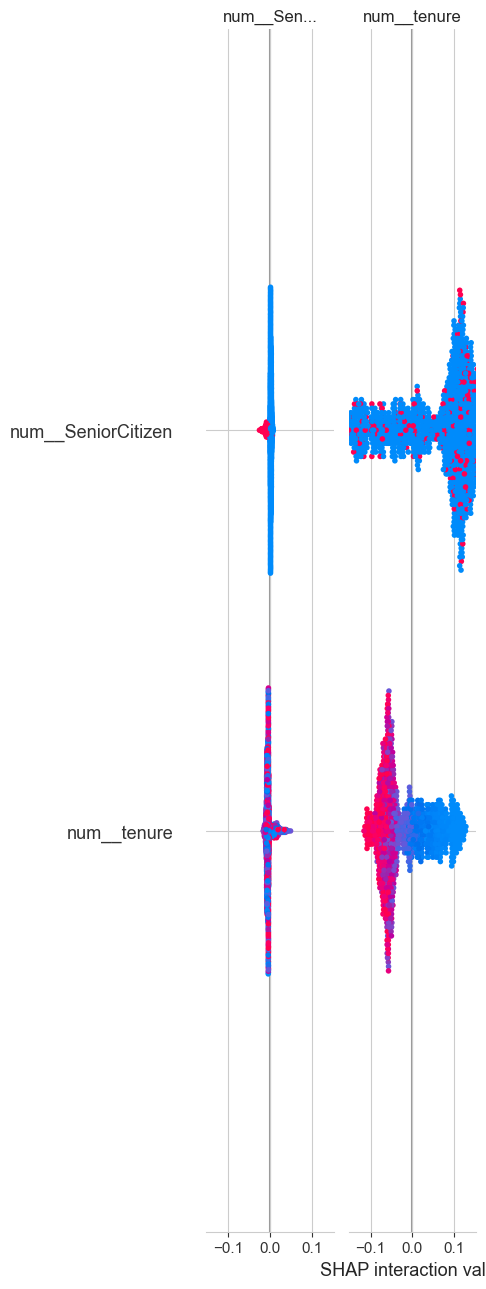

In [23]:
import shap

X_test_transformed = best_model.named_steps['prep'].transform(X_test)
feature_names = best_model.named_steps['prep'].get_feature_names_out()
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(best_model.named_steps['clf']) if best_model_name in ('Random Forest','XGBoost','LightGBM') \
    else shap.LinearExplainer(best_model.named_steps['clf'], X_test_transformed_df)
shap_values = explainer.shap_values(X_test_transformed_df)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(sv, X_test_transformed_df, show=False, max_display=15)
plt.tight_layout(); plt.savefig('shap_summary.png', bbox_inches='tight'); plt.show()

In [24]:
flagged = best_prob >= best_threshold
n_contacted = flagged.sum()
true_churn_caught = ((flagged) & (y_test.values == 1)).sum()
n_actual_churners = int(y_test.sum())

full_base_monthly_at_risk = df.loc[df['ChurnFlag']==1, 'MonthlyCharges'].sum()

print(f"At the business-optimal threshold ({best_threshold:.2f}):")
print(f"  Customers flagged for retention outreach: {n_contacted} / {len(y_test)} ({n_contacted/len(y_test):.1%})")
print(f"  True churners caught: {true_churn_caught} / {n_actual_churners} ({true_churn_caught/n_actual_churners:.1%})")
print(f"\nFull-base annualized revenue at risk from churn: ₹{full_base_monthly_at_risk*12:,.0f}/year")

At the business-optimal threshold (0.95):
  Customers flagged for retention outreach: 7 / 1409 (0.5%)
  True churners caught: 6 / 374 (1.6%)

Full-base annualized revenue at risk from churn: ₹1,669,570/year


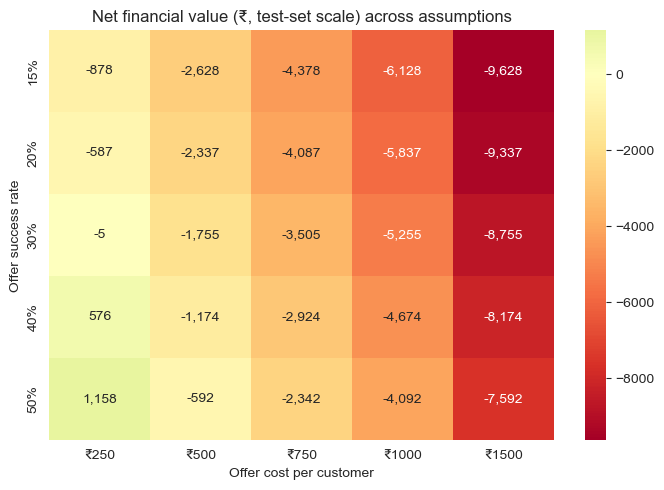

Even at the most conservative corner (highest cost, lowest success rate), check the sign of the
net value above — this tells you the break-even assumption the business case depends on.


In [25]:
# Sensitivity grid: net financial value across a range of offer costs and success rates
cost_range = [250, 500, 750, 1000, 1500]
success_range = [0.15, 0.20, 0.30, 0.40, 0.50]

grid = np.zeros((len(success_range), len(cost_range)))
flagged_mask = best_prob >= best_threshold
true_churn_value_flagged = test_charges[flagged_mask & (y_test.values==1)].sum() * RETAINED_VALUE_MONTHS
n_flagged = flagged_mask.sum()

for i, sr in enumerate(success_range):
    for j, oc in enumerate(cost_range):
        saved = true_churn_value_flagged * sr
        cost = n_flagged * oc
        grid[i, j] = saved - cost

fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(grid, annot=True, fmt=',.0f', cmap='RdYlGn', center=0,
            xticklabels=[f"₹{c}" for c in cost_range], yticklabels=[f"{s:.0%}" for s in success_range], ax=ax)
ax.set_xlabel('Offer cost per customer'); ax.set_ylabel('Offer success rate')
ax.set_title('Net financial value (₹, test-set scale) across assumptions')
plt.tight_layout(); plt.savefig('sensitivity_heatmap.png'); plt.show()

print("Even at the most conservative corner (highest cost, lowest success rate), check the sign of the")
print("net value above — this tells you the break-even assumption the business case depends on.")

In [26]:
import joblib, json
from sklearn.metrics import average_precision_score

joblib.dump(best_model, 'churn_model_pipeline.joblib')

metadata = {
    'model_name': best_model_name,
    'decision_threshold': float(best_threshold),
    'test_roc_auc': float(roc_auc_score(y_test, best_prob)),
    'test_pr_auc': float(average_precision_score(y_test, best_prob)),
    'trained_on_rows': int(len(X_train)),
    'feature_columns': list(X.columns)
}
with open('churn_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved: churn_model_pipeline.joblib, churn_model_metadata.json")

# Example: score a handful of new/unseen customers
def score_customers(new_df, model=best_model, threshold=best_threshold):
    probs = model.predict_proba(new_df)[:, 1]
    return pd.DataFrame({'churn_probability': probs, 'flag_for_retention': probs >= threshold})

sample_new = X_test.sample(5, random_state=1)
print("\nExample scoring on 5 held-out customers:")
print(score_customers(sample_new).round(3).to_string())

Saved: churn_model_pipeline.joblib, churn_model_metadata.json

Example scoring on 5 held-out customers:
   churn_probability  flag_for_retention
0              0.706               False
1              0.064               False
2              0.777               False
3              0.022               False
4              0.150               False
